Import Libraries

In [4]:
import numpy as np
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

Prepare & Read Data

In [5]:
# Your Kaggle credentials
os.environ['KAGGLE_USERNAME'] = 'malakkhaledaboahmed'
os.environ['KAGGLE_KEY'] = 'KGAT_a889cbfa4d477a03bf8001ea39431428'

In [6]:
df = pd.read_csv('AirQuality.csv', sep=';', decimal=',')

Exploratory Data Analysis

In [7]:
df.head(10)
#Displays the first 10 rows to understand the data structure.
#Observation: We see -200 (missing value marker) and two empty columns at the end.

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN
5,10/03/2004,23.00.00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848,NaN,NaN
6,11/03/2004,00.00.00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603,NaN,NaN
7,11/03/2004,01.00.00,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702,NaN,NaN
8,11/03/2004,02.00.00,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648,NaN,NaN
9,11/03/2004,03.00.00,0.6,1010.0,19.0,1.7,561.0,-200.0,1705.0,-200.0,1235.0,501.0,10.3,60.2,0.7517,NaN,NaN


In [8]:
#delete last 2 columns(unnamed)
df.drop(df.columns[-2:], axis=1, inplace=True)

In [9]:
df.shape

(9471, 15)

In [10]:
df = df.replace(-200, np.nan)
#-200 is an invalid value (air pollution can't be negative).

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         7674 non-null   float64
 3   PT08.S1(CO)    8991 non-null   float64
 4   NMHC(GT)       914 non-null    float64
 5   C6H6(GT)       8991 non-null   float64
 6   PT08.S2(NMHC)  8991 non-null   float64
 7   NOx(GT)        7718 non-null   float64
 8   PT08.S3(NOx)   8991 non-null   float64
 9   NO2(GT)        7715 non-null   float64
 10  PT08.S4(NO2)   8991 non-null   float64
 11  PT08.S5(O3)    8991 non-null   float64
 12  T              8991 non-null   float64
 13  RH             8991 non-null   float64
 14  AH             8991 non-null   float64
dtypes: float64(13), str(2)
memory usage: 1.2 MB


In [12]:
df.describe()
#Calculates mean, std, min, max for numeric columns to understand data distribution

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [13]:
df.isnull().sum()

Date              114
Time              114
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(113)

In [15]:
# Merges Date and Time columns into a single datetime column for time-series analysis.
df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'].astype(str).str.replace('.', ':'), errors='coerce')

#Extracts useful features (hour, day name, month) from the timestamp.
df['Hour'] = df['Timestamp'].dt.hour
df['Day_of_Week'] = df['Timestamp'].dt.day_name()
df['Month'] = df['Timestamp'].dt.month

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Day_of_Week'] = pd.Categorical(df['Day_of_Week'], categories=days_order, ordered=True)

df['Time'] = df['Timestamp'].dt.time

print("Remaining Columns:", df.columns.tolist())
df.head()


Remaining Columns: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Timestamp', 'Hour', 'Day_of_Week', 'Month']


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Timestamp,Hour,Day_of_Week,Month
0,10/03/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-10-03 18:00:00,18.0,Sunday,10.0
1,10/03/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-10-03 19:00:00,19.0,Sunday,10.0
2,10/03/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-10-03 20:00:00,20.0,Sunday,10.0
3,10/03/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-10-03 21:00:00,21.0,Sunday,10.0
4,10/03/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-10-03 22:00:00,22.0,Sunday,10.0


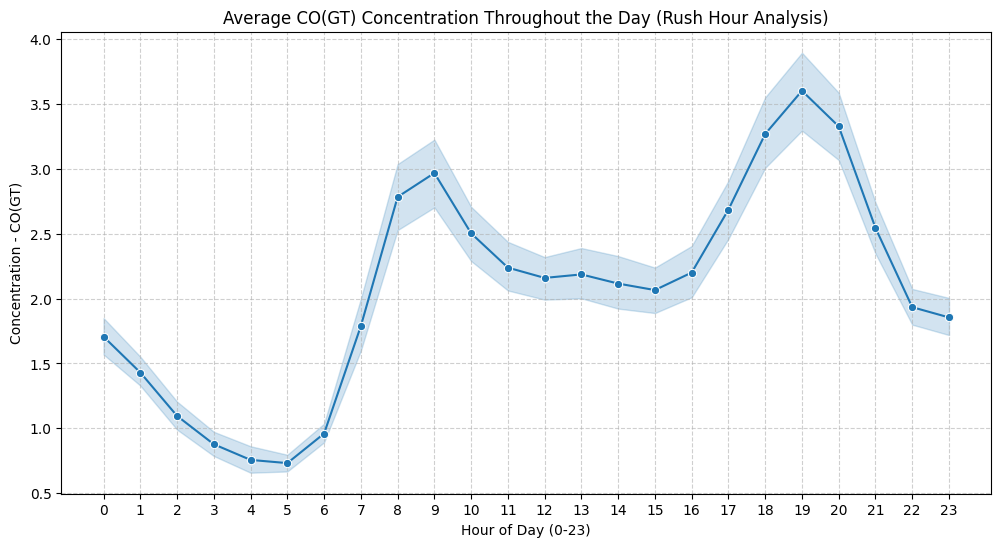

In [16]:
plt.figure(figsize=(12, 6))
# Line plot showing average CO concentration for each hour of the day
sns.lineplot(data=df, x='Hour', y='CO(GT)', marker='o', color='tab:blue')
plt.title('Average CO(GT) Concentration Throughout the Day (Rush Hour Analysis)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Concentration - CO(GT)')
plt.show()
#CO peaks during morning (8-9 AM) and evening (6-8 PM) rush hours.

## **Visulization before Preprocessing**

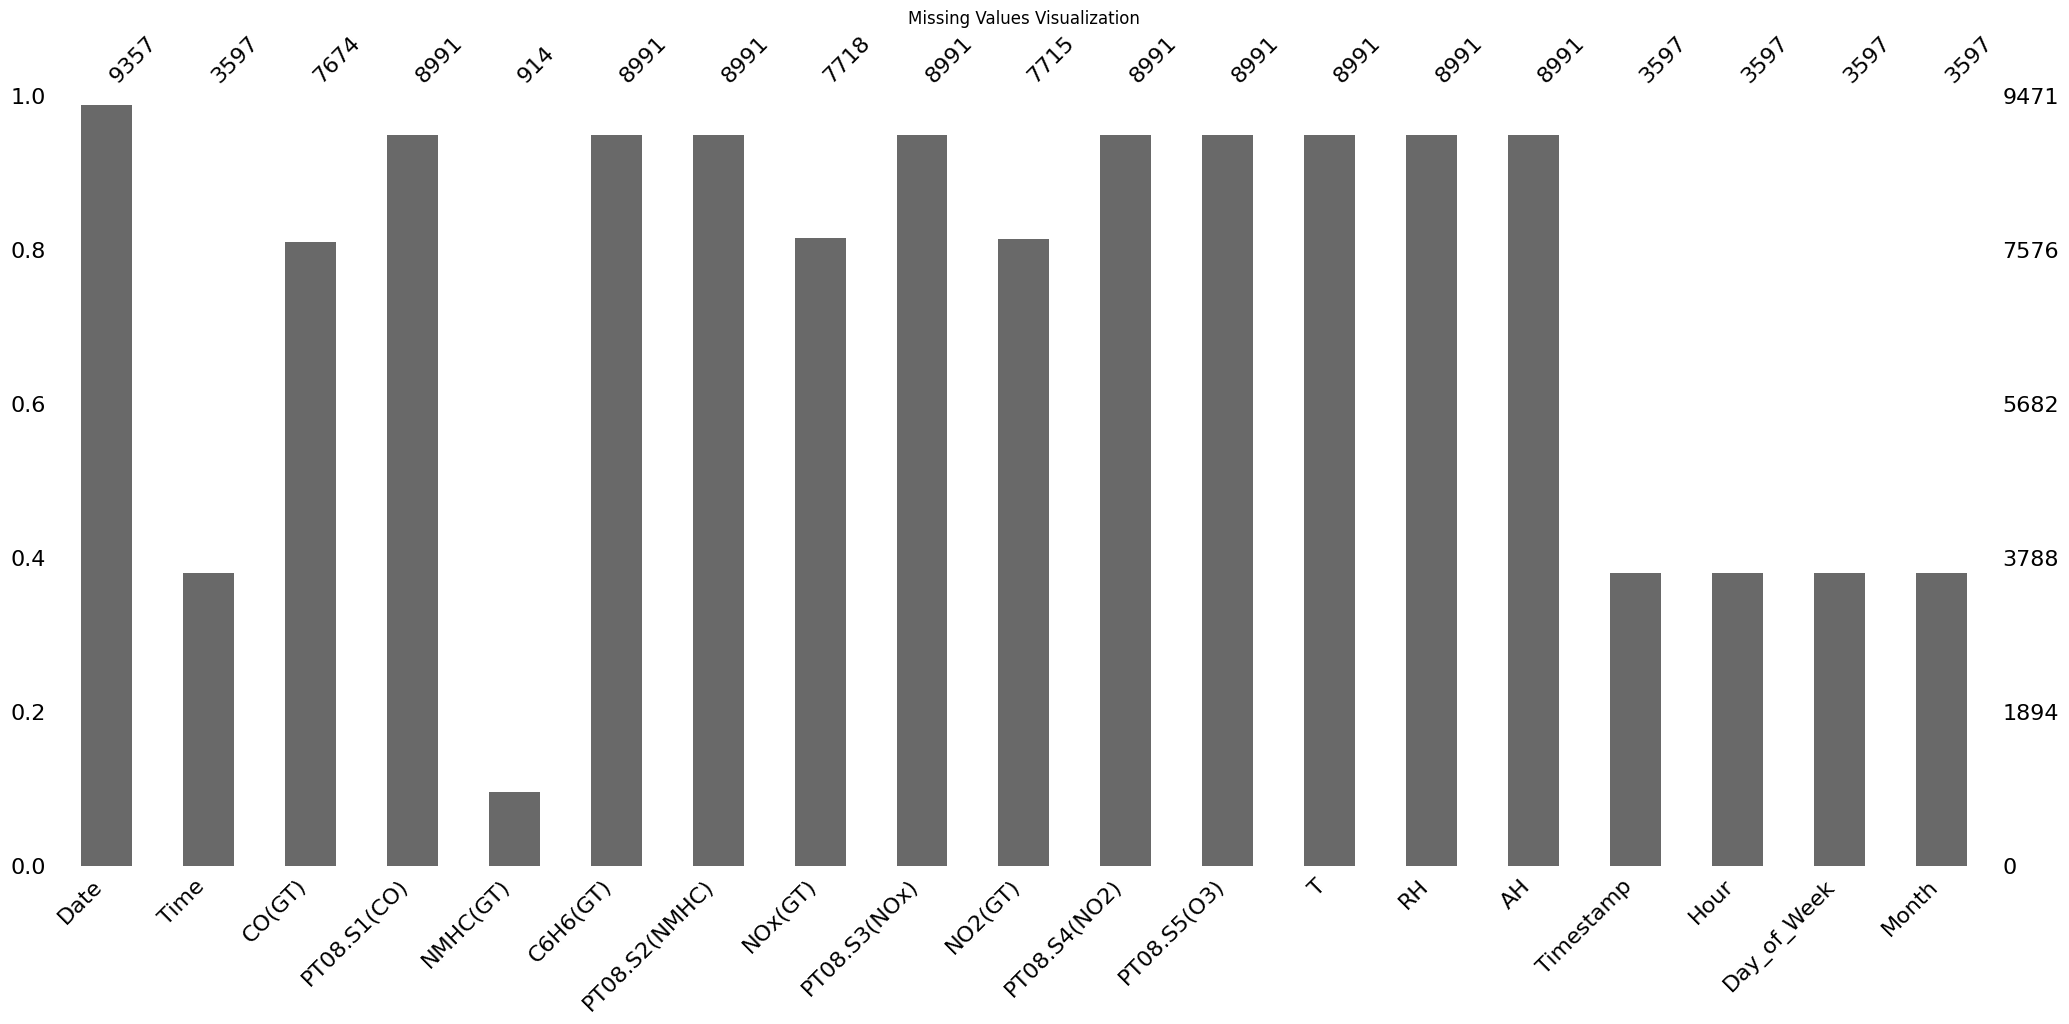

In [17]:
plt.figure(figsize=(12,6))
msno.bar(df)
plt.title("Missing Values Visualization")
plt.show()
#Bar chart showing missing values. NMHC(GT) is almost completely empty

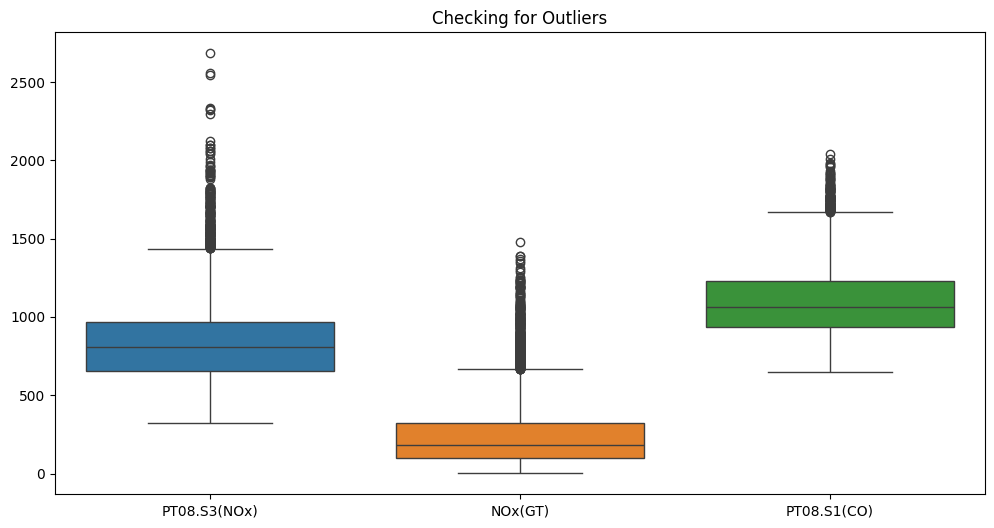

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
cols_to_check = ['PT08.S3(NOx)', 'NOx(GT)', 'PT08.S1(CO)']
sns.boxplot(data=df[cols_to_check])
plt.title("Checking for Outliers")
plt.show()
 #Many black dots outside the whiskers → outliers exist.

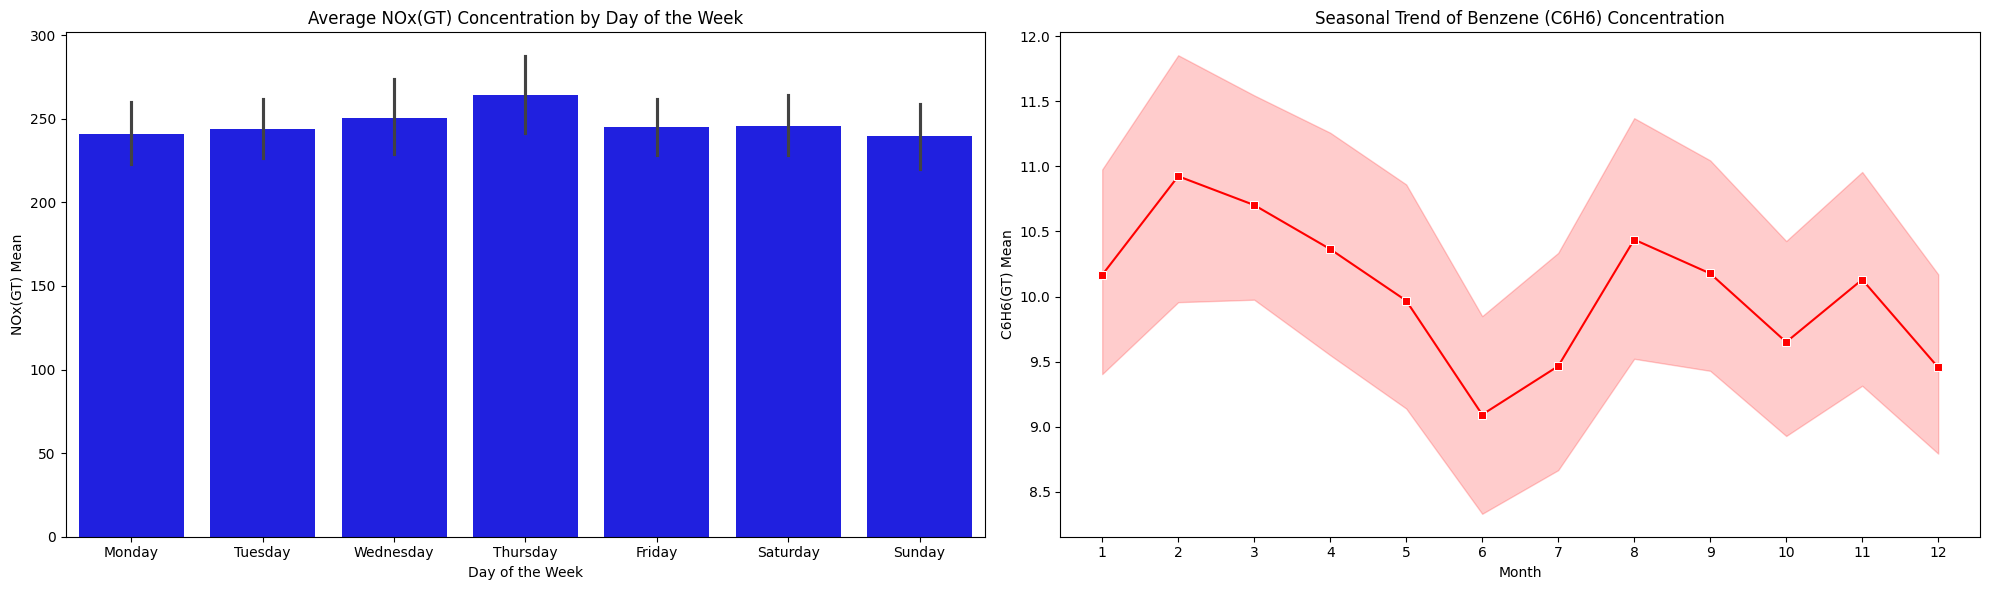

In [19]:
# Create a figure with two subplots side-by-side
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# Plot 1: Average Nitrogen Oxides (NOx) by Day of the Week (Bar Chart)
sns.barplot(data=df, x='Day_of_Week', y='NOx(GT)', ax=ax[0], color="blue")
ax[0].set_title('Average NOx(GT) Concentration by Day of the Week')
ax[0].set_xlabel('Day of the Week')
ax[0].set_ylabel('NOx(GT) Mean')

# Plot 2: Seasonal Trend of Benzene (C6H6) across Months (Line Plot)
sns.lineplot(data=df, x='Month', y='C6H6(GT)', marker='s', ax=ax[1], color='red')
ax[1].set_title('Seasonal Trend of Benzene (C6H6) Concentration')
ax[1].set_xlabel('Month')
ax[1].set_ylabel('C6H6(GT) Mean')
ax[1].set_xticks(range(1, 13))

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()
#NOx is higher on weekdays, lower on weekends.
#Benzene is higher in winter months (Nov-Feb), lower in summer.

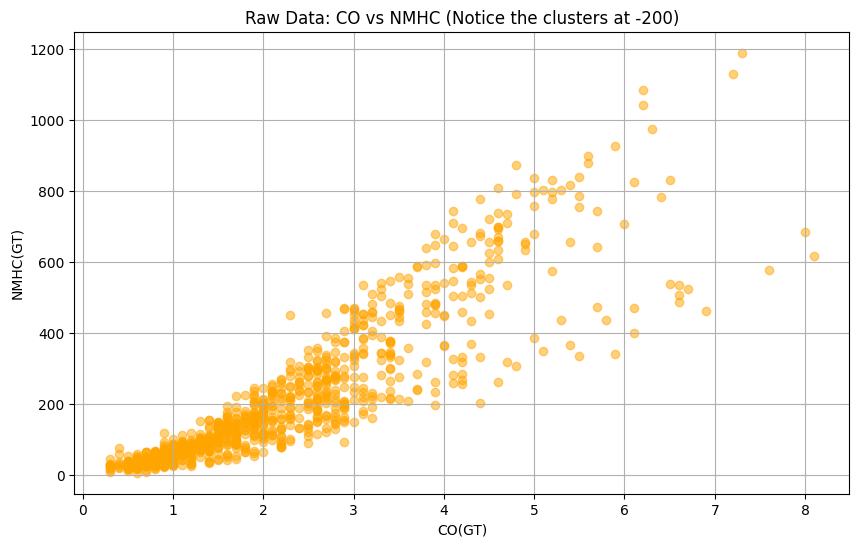

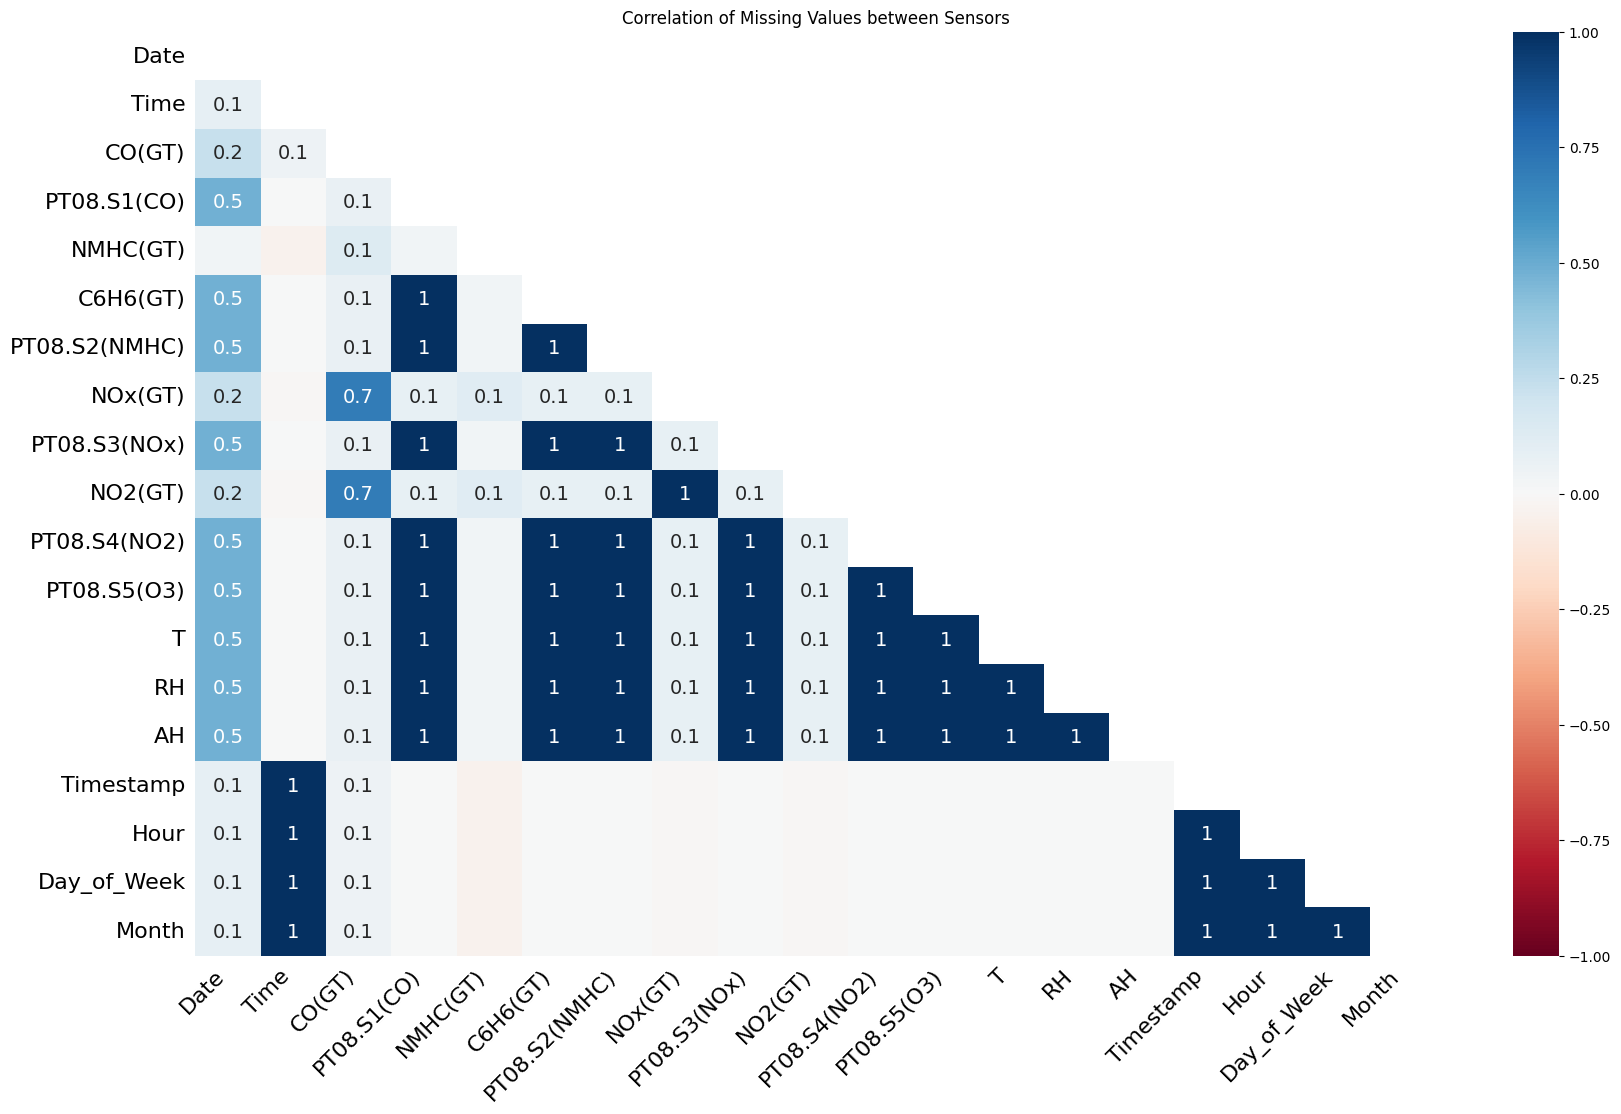

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df['CO(GT)'], df['NMHC(GT)'], alpha=0.5, color='orange')
plt.title('Raw Data: CO vs NMHC (Notice the clusters at -200)')
plt.xlabel('CO(GT)')
plt.ylabel('NMHC(GT)')
plt.grid(True)
plt.show()

# هيت ماب بتوضح هل فيه علاقة بين فقدان البيانات في الأعمدة المختلفة
msno.heatmap(df.replace(-200, np.nan))
plt.title('Correlation of Missing Values between Sensors')
plt.show()

## **Preprocessing**

Dealing With Duplicates

In [21]:
# Remove duplicate rows
df = df.drop_duplicates()

Dealing with Nulls

In [22]:
df = df.drop('NMHC(GT)', axis=1)
df = df.drop('Date', axis=1)
df = df.drop('Time', axis=1)

In [23]:
#ffill() fills missing values with the previous row's value. bfill() fills remaining ones with the next row's value. Good for time-series data.
df = df.ffill().bfill()

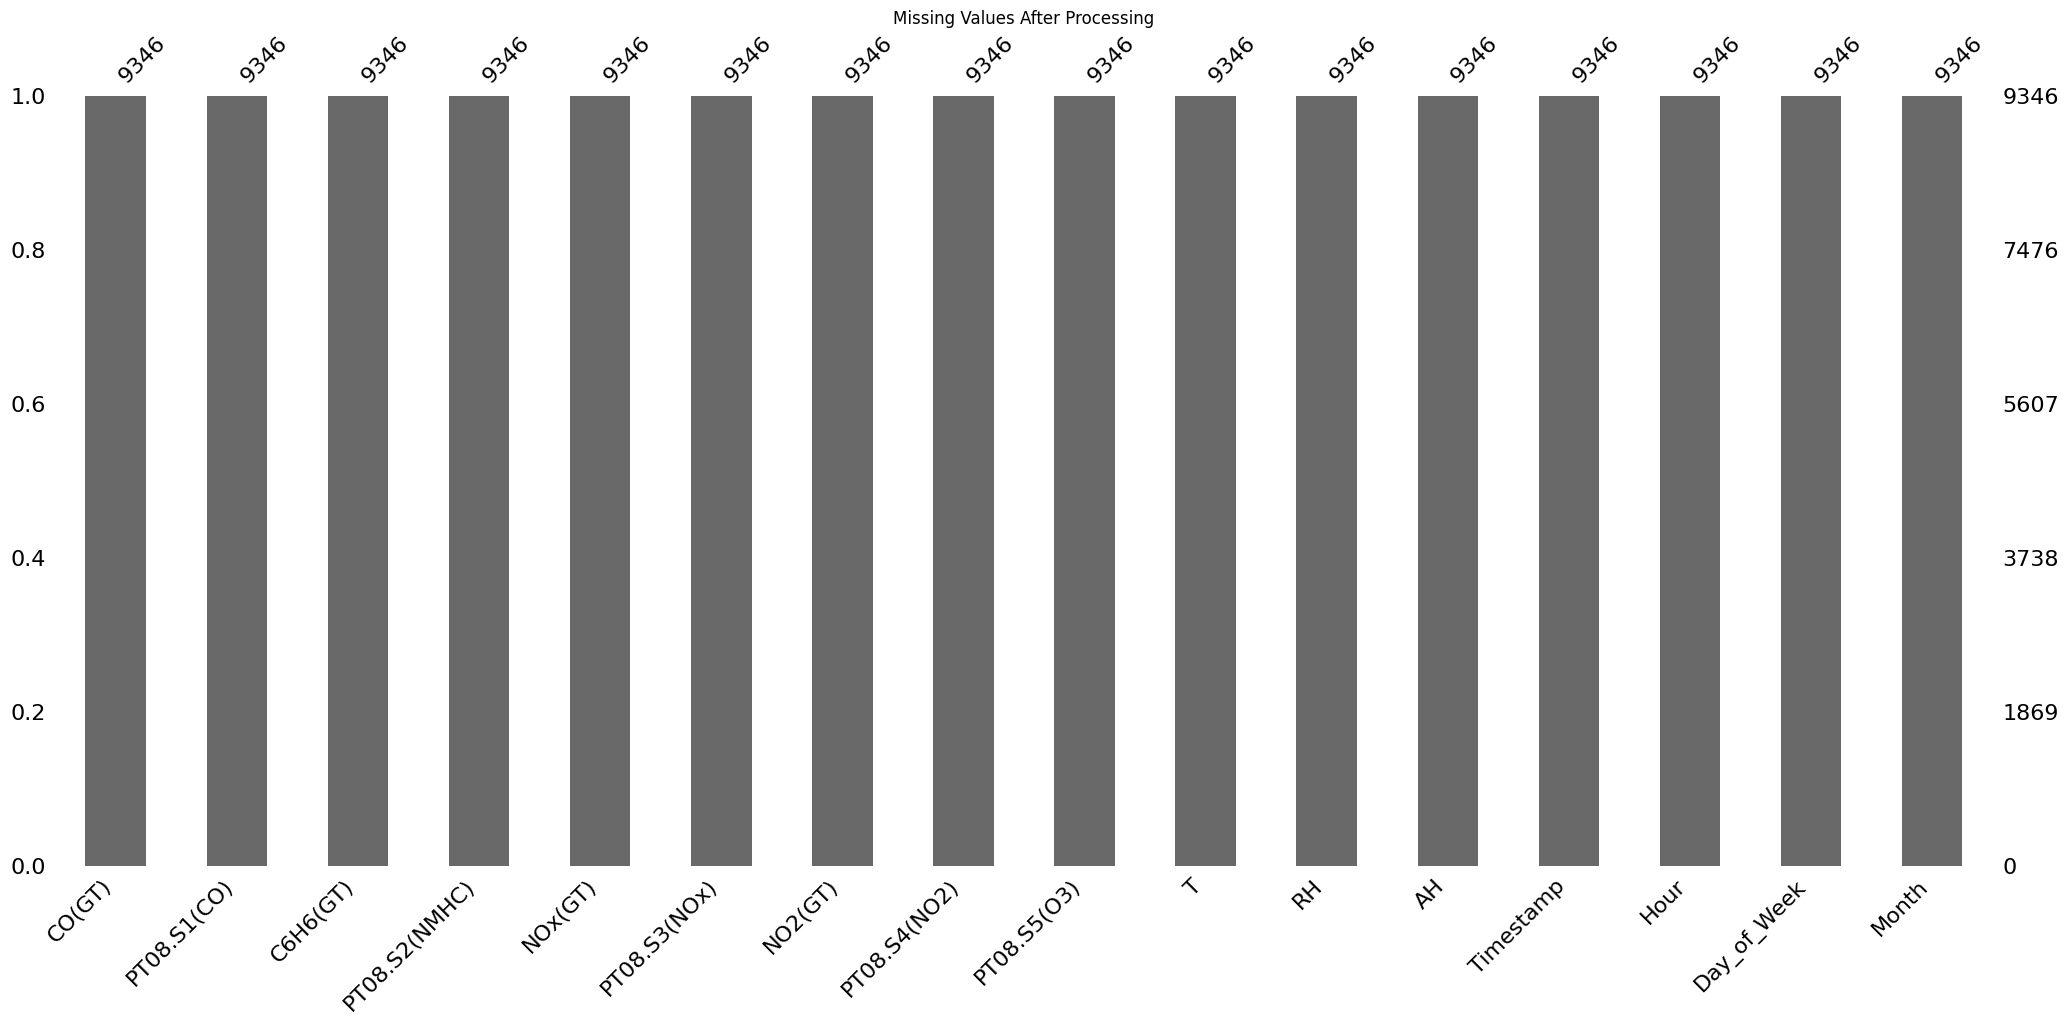

In [24]:
import missingno as msno
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
msno.bar(df)
plt.title("Missing Values After Processing")
plt.show()
#All bars are solid dark color → no missing values remain.


In [25]:
df_categorical = df.select_dtypes(include=['object'])
df_numerical = df.select_dtypes(exclude=['object'])

In [26]:
print("categorical columns:")
print(df_categorical.columns)
print("numerical columns:")
print(df_numerical.columns)


categorical columns:
Index([], dtype='str')
numerical columns:
Index(['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)',
       'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH',
       'AH', 'Timestamp', 'Hour', 'Day_of_Week', 'Month'],
      dtype='str')


Dealing with outliers

In [27]:
# Columns that actually have outliers (based on your IQR results)
cols = ['PT08.S3(NOx)', 'NOx(GT)', 'PT08.S1(CO)']

In [28]:
print("=== Outlier Count using IQR Method ===\n")

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_iqr) | (df[col] > upper_iqr)].shape[0]

    print(f"{col}: {outliers} outliers")

=== Outlier Count using IQR Method ===

PT08.S3(NOx): 239 outliers
NOx(GT): 508 outliers
PT08.S1(CO): 105 outliers


In [29]:
print("\n=== Applying Percentile Clipping ===\n")

for col in cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df[col] = df[col].clip(lower=lower, upper=upper)

    print(f"{col}: clipped between {lower:.2f} and {upper:.2f}")


=== Applying Percentile Clipping ===

PT08.S3(NOx): clipped between 407.00 and 1652.10
NOx(GT): clipped between 19.00 and 971.85
PT08.S1(CO): clipped between 741.00 and 1704.00


## **Visulization after Preprocessing**

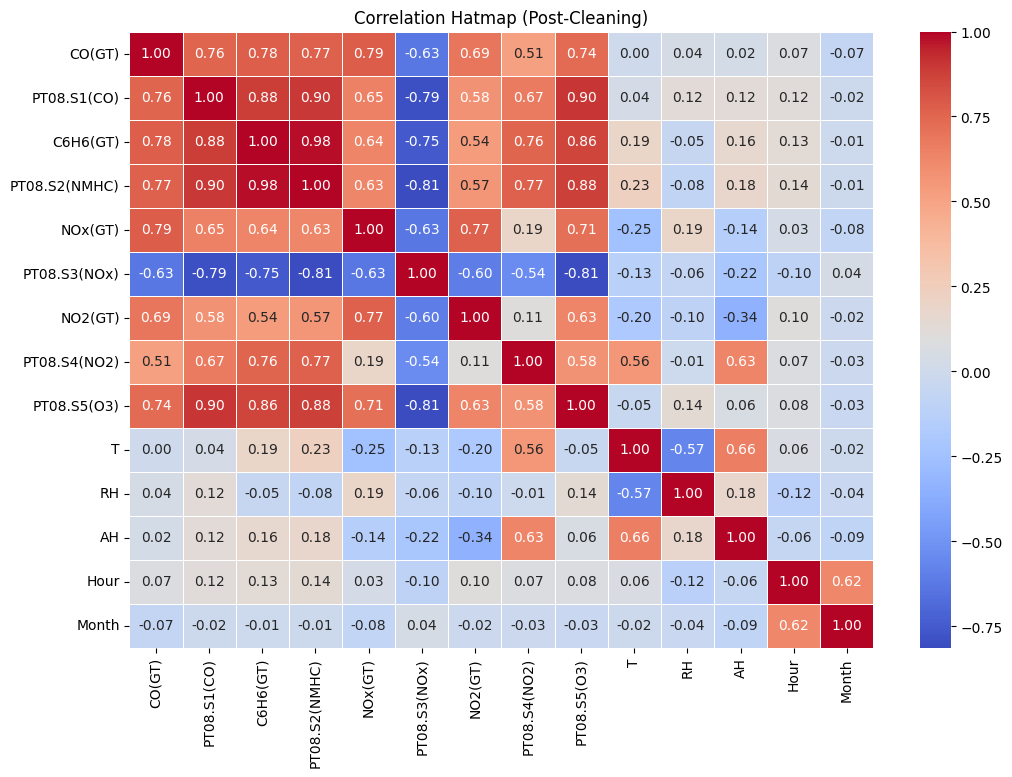

In [30]:
# Create a correlation heatmap to identify highly related features (Multicollinearity).
# This helps in Feature Selection by identifying sensors that provide redundant information.
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Hatmap (Post-Cleaning)')
plt.show()

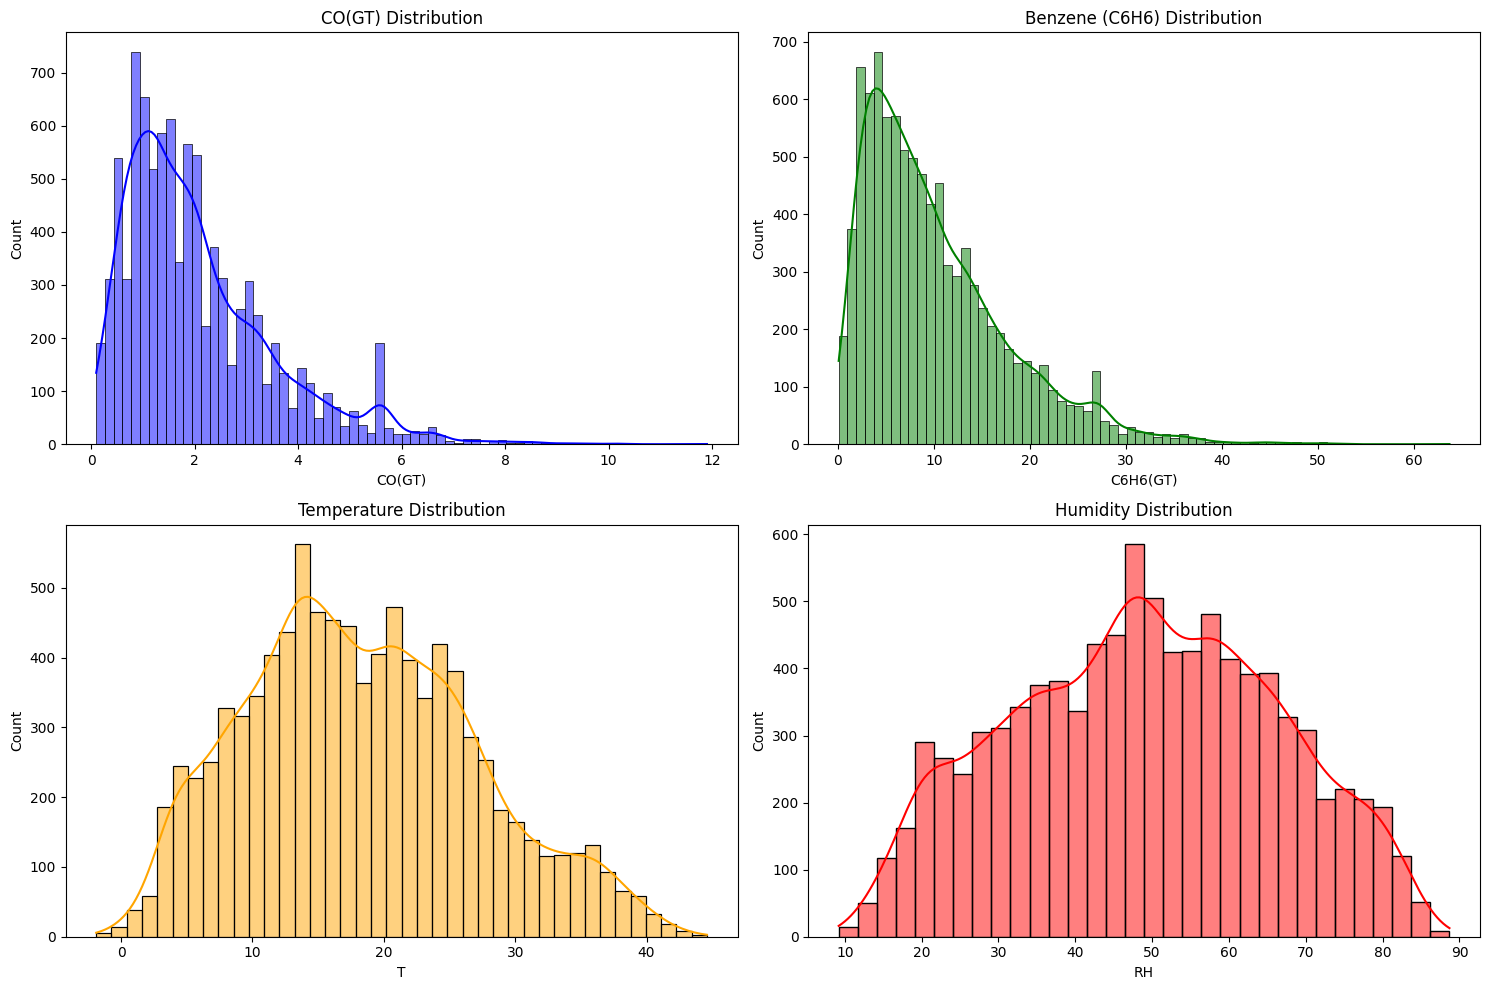

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df['CO(GT)'].dropna(), kde=True, ax=axes[0,0], color='blue').set_title('CO(GT) Distribution')
sns.histplot(df['C6H6(GT)'].dropna(), kde=True, ax=axes[0,1], color='green').set_title('Benzene (C6H6) Distribution')
sns.histplot(df['T'].dropna(), kde=True, ax=axes[1,0], color='orange').set_title('Temperature Distribution')
sns.histplot(df['RH'].dropna(), kde=True, ax=axes[1,1], color='red').set_title('Humidity Distribution')

plt.tight_layout()
plt.show()

## **Feature Engineering**

In [32]:
# --- 1. Time-based and human activity features ---
df['Hour'] = df['Timestamp'].dt.hour

# Rush hour feature (7–9 AM and 5–7 PM)
df['Is_RushHour'] = df['Hour'].apply(lambda x: 1 if x in [7, 8, 9, 17, 18, 19] else 0)

# Working day feature (0 for weekends, 1 for weekdays)
df['Is_WorkingDay'] = df['Timestamp'].dt.dayofweek.apply(lambda x: 0 if x >= 5 else 1)

# Add season feature
if 'Season' not in df.columns:
    def get_season(month):
        if month in [12, 1, 2]: return 'Winter'
        elif month in [3, 4, 5]: return 'Spring'
        elif month in [6, 7, 8]: return 'Summer'
        else: return 'Autumn'
    df['Season'] = df['Month'].apply(get_season)

# Convert seasons into dummy variables
season_dummies = pd.get_dummies(df['Season'], prefix='Season').astype(int)
df = pd.concat([df, season_dummies], axis=1)

# --- 2. Lag and rolling statistical features ---
df['CO_lag1'] = df['CO(GT)'].shift(1)
df['T_lag1'] = df['T'].shift(1)
df['NOx_lag1'] = df['NOx(GT)'].shift(1)
df['CO_mean_3h'] = df['CO(GT)'].rolling(window=3).mean()
df['S1_std_6h'] = df['PT08.S1(CO)'].rolling(window=6).std()
df['Temp_Diff'] = df['T'].diff().fillna(0)

# --- 3. Additional features (atmospheric interactions) ---
df['T_RH_Interaction'] = df['T'] * df['RH']

In [33]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select sensor columns and initialize scaler
sensor_cols = ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'NO2(GT)']
scaler = StandardScaler()

# Apply scaling to the sensor data
sensors_scaled = scaler.fit_transform(df[sensor_cols])

# Perform PCA
pca = PCA(n_components=2)
sensors_pca = pca.fit_transform(sensors_scaled)

# Add PCA components to dataframe
df['Sensor_PCA1'] = sensors_pca[:, 0]
df['Sensor_PCA2'] = sensors_pca[:, 1]

In [34]:
df['CO_Trend'] = df['CO(GT)'].diff()

def get_day_period(h):
    if 6 <= h <= 10: return 1
    if 16 <= h <= 20: return 2
    if 21 <= h or h <= 5: return 3
    return 0

df['Day_Period'] = df['Hour'].apply(get_day_period)
df['CO_Volatility_3h'] = df['CO(GT)'].rolling(window=3).std()
df['hour_sin'] = np.sin(2 * np.pi * df['Hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour']/24)

print("--- [Step 1] Manual Feature Engineering Output ---")
print(f"Total columns in main df: {df.shape[1]}")
display(df.head())

--- [Step 1] Manual Feature Engineering Output ---
Total columns in main df: 37


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,...,S1_std_6h,Temp_Diff,T_RH_Interaction,Sensor_PCA1,Sensor_PCA2,CO_Trend,Day_Period,CO_Volatility_3h,hour_sin,hour_cos
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,...,NaN,0.0,665.04,0.728627,-0.669277,NaN,2,NaN,-1.000000,-1.836970e-16
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,...,NaN,-0.3,634.41,-0.042080,-0.793007,-0.6,2,NaN,-0.965926,2.588190e-01
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,...,NaN,-1.4,642.60,0.382994,-0.515183,0.2,2,0.305505,-0.866025,5.000000e-01
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,...,NaN,-0.9,660.00,0.506982,-0.292162,0.0,3,0.115470,-0.707107,7.071068e-01
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,...,NaN,0.2,667.52,-0.221659,-0.073418,-0.6,3,0.346410,-0.500000,8.660254e-01


In [35]:
# --- FINAL FEATURE SELECTION & REFINEMENT FOR CLUSTERING ---

# Define the most informative features for Clustering
# We prioritize temporal behavior, pollution trends, PCA sensor fusion,
# volatility, and atmospheric interactions

final_feature_columns = [

    'CO_mean_3h',        # Rolling mean of CO
    'CO_Trend',          # Hourly CO change
    'CO_Volatility_3h',  # Pollution fluctuation
    'CO_lag1',           # Previous hour memory

    'Sensor_PCA1',       # Main sensor behavior pattern
    'Sensor_PCA2',       # Secondary sensor pattern

    'T_RH_Interaction',  # Temperature-Humidity interaction

    'PT08.S2(NMHC)',     # Hydrocarbon sensor
    'C6H6(GT)',          # Benzene level
    'PT08.S4(NO2)',      # NO2 sensor
    'NOx(GT)'            # Nitrogen Oxides
]

# Create final cleaned dataset for clustering
# Drop rows with NaN values caused by lag / rolling calculations

df_final_clean = df.dropna(subset=final_feature_columns)

# Final feature matrix
X_final_v3 = df_final_clean[final_feature_columns]

print("Dataset successfully prepared for Clustering.")
print(f"Number of Features: {X_final_v3.shape[1]}")
print(f"Dataset Shape: {X_final_v3.shape}")
print("Final Features:")
print(list(X_final_v3.columns))
display(X_final_v3.head())

Dataset successfully prepared for Clustering.
Number of Features: 11
Dataset Shape: (9344, 11)
Final Features:
['CO_mean_3h', 'CO_Trend', 'CO_Volatility_3h', 'CO_lag1', 'Sensor_PCA1', 'Sensor_PCA2', 'T_RH_Interaction', 'PT08.S2(NMHC)', 'C6H6(GT)', 'PT08.S4(NO2)', 'NOx(GT)']


,CO_mean_3h,CO_Trend,CO_Volatility_3h,CO_lag1,Sensor_PCA1,Sensor_PCA2,T_RH_Interaction,PT08.S2(NMHC),C6H6(GT),PT08.S4(NO2),NOx(GT)
2,2.266667,0.2,0.305505,2.0,0.382994,-0.515183,642.60,939.0,9.0,1555.0,131.0
3,2.133333,0.0,0.115470,2.2,0.506982,-0.292162,660.00,948.0,9.2,1584.0,172.0
4,2.000000,-0.6,0.346410,2.2,-0.221659,-0.073418,667.52,836.0,6.5,1490.0,131.0
5,1.666667,-0.4,0.503322,1.6,-0.902565,-0.162711,663.04,750.0,4.7,1393.0,89.0
6,1.333333,0.0,0.230940,1.2,-1.317309,-0.345719,641.84,690.0,3.6,1333.0,62.0


In [36]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select features (use the names defined in Feature Engineering)
features_to_scale = [col for col in final_feature_columns if col not in ['hour_sin', 'hour_cos']]
circular_features = ['hour_sin', 'hour_cos']

#  Apply scaling only to non-circular features using RobustScaler
robust_scaler = RobustScaler()
scaled_data = robust_scaler.fit_transform(df_final_clean[features_to_scale])

#  Combine scaled features with sin and cos (without scaling)
X_scaled_part = pd.DataFrame(scaled_data, columns=features_to_scale, index=df_final_clean.index)
X_final = pd.concat([X_scaled_part, df_final_clean[circular_features]], axis=1)

print("Scale Done (Excluding Sin/Cos)! Ready for Elbow Method.")

Scale Done (Excluding Sin/Cos)! Ready for Elbow Method.


Model Devolopment

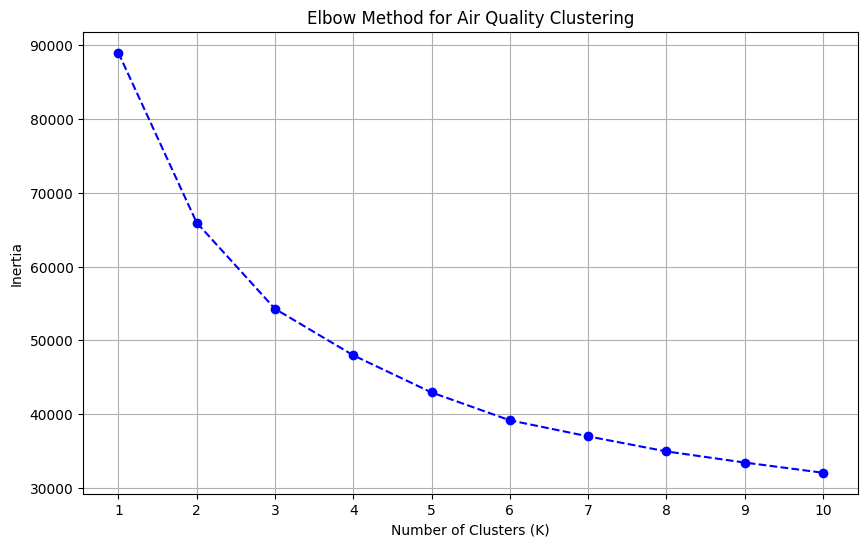

In [37]:
#  Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_final)
    inertia.append(kmeans.inertia_)

# 5. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Air Quality Clustering')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [38]:
from sklearn.cluster import KMeans

#  Apply the model with 3 clusters
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_final)

# Add the results to the original dataset
df_final_clean['Cluster'] = clusters

print("Clustering Complete! Each row is now assigned to a group (0, 1, or 2).")

# Check the number of points in each cluster
print("\nPoints per Cluster:")
print(df_final_clean['Cluster'].value_counts())

Clustering Complete! Each row is now assigned to a group (0, 1, or 2).

Points per Cluster:
Cluster
0    6418
2    1757
1    1169
Name: count, dtype: int64


In [39]:
# Analyze clusters based on average values
analysis = df_final_clean.groupby('Cluster').agg({
    'CO(GT)': 'mean',
    'NOx(GT)': 'mean',
    'T': 'mean',
    'Hour': 'mean',
    'Is_RushHour': 'mean' # Shows the proportion of rush hour occurrence in each cluster
}).sort_values(by='CO(GT)') # Sort by carbon monoxide level

print("Cluster Analysis Table")
display(analysis)

Cluster Analysis Table


,CO(GT),NOx(GT),T,Hour,Is_RushHour
Cluster,,,,,
0,1.357089,151.546276,18.366734,18.278591,0.068246
2,3.360501,409.385344,18.110131,19.058623,0.082527
1,4.138323,466.774893,18.257913,19.448246,0.268606


In [40]:
from sklearn.metrics import silhouette_score

#  calc Silhouette Score
score = silhouette_score(X_final, clusters)

print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.339


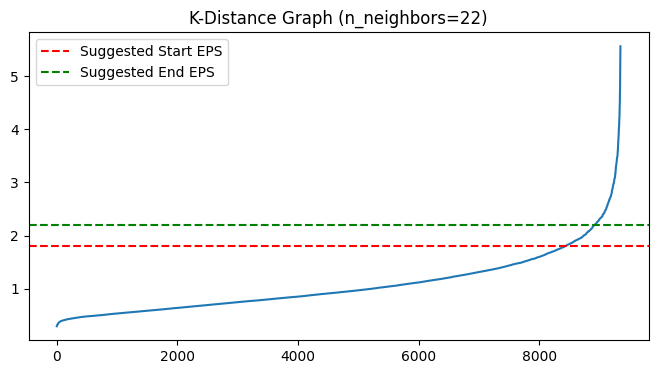

Optimal eps found: 1.00 with Silhouette: 0.4384


In [41]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  Define a consistent min_samples value ---
target_min_samples = 22

#  Plot K-Distance based on the new min_samples ---
nn = NearestNeighbors(n_neighbors=target_min_samples)
nn.fit(X_final)
distances, _ = nn.kneighbors(X_final)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.axhline(y=1.8, color='r', linestyle='--', label='Suggested Start EPS')
plt.axhline(y=2.2, color='g', linestyle='--', label='Suggested End EPS')
plt.title(f"K-Distance Graph (n_neighbors={target_min_samples})")
plt.legend()
plt.show()

#  Improve the loop to search for the best eps ---
eps_range = np.arange(1.0, 2.6, 0.1)
scores = []
noise_ratios = []

for eps in eps_range:
    db = DBSCAN(eps=eps, min_samples=target_min_samples).fit(X_final)
    labels = db.labels_

    mask = labels != -1
    n_clusters = len(set(labels[mask]))

    if n_clusters > 1:
        # Calculate the score using only non-noise points
        score = silhouette_score(X_final[mask], labels[mask])
        scores.append(score)
    else:
        scores.append(-1)

    noise_ratios.append(np.sum(labels == -1) / len(labels))

# Select the best eps
optimal_eps = eps_range[np.argmax(scores)]
print(f"Optimal eps found: {optimal_eps:.2f} with Silhouette: {max(scores):.4f}")

Number of clusters found: 3
Noise Percentage: 29.87%


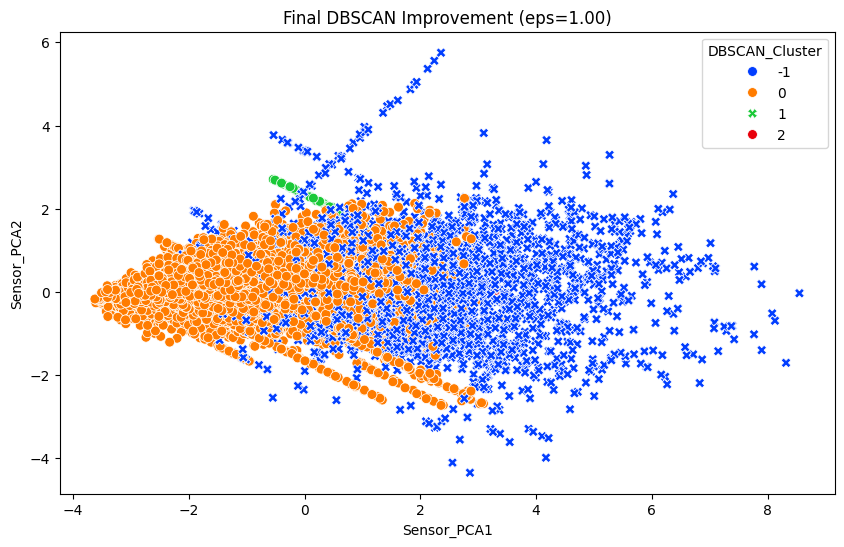

,CO(GT),NOx(GT),T,Is_RushHour
DBSCAN_Cluster,,,,
-1,3.437048,435.193085,17.288785,0.229308
0,1.449412,150.938757,18.691834,0.039437
1,5.600000,540.000000,20.174576,0.033898
2,5.600000,540.000000,26.285714,0.000000


In [42]:
# Apply the final model
best_dbscan = DBSCAN(eps=optimal_eps, min_samples=target_min_samples)
db_labels = best_dbscan.fit_predict(X_final)
df_final_clean['DBSCAN_Cluster'] = db_labels

#  Analyze the results
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"Number of clusters found: {n_clusters}")
print(f"Noise Percentage: {np.sum(db_labels == -1)/len(db_labels)*100:.2f}%")

# Plot for verification
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_final_clean,
    x='Sensor_PCA1', y='Sensor_PCA2',
    hue='DBSCAN_Cluster', palette='bright',
    style=(df_final_clean['DBSCAN_Cluster'] == -1),
    markers={True: 'X', False: 'o'}, s=50
)
plt.title(f'Final DBSCAN Improvement (eps={optimal_eps:.2f})')
plt.show()

# Cluster averages
display(df_final_clean.groupby('DBSCAN_Cluster')[['CO(GT)', 'NOx(GT)', 'T', 'Is_RushHour']].mean())